<span style="color:red;font-size:2em;font-weight:bold"> PARTIES 2 et 3 - Tracking des expérimentations via MLFlow</span>

<span style="color:blue;font-size:1.5em;font-weight:bold;background-color:yellow"> Modules </span>

In [1]:
# Module pour recharger un module sans redemarrer le kernel
# import importlib
%load_ext autoreload
%autoreload 2

In [ ]:
# Roots
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

#Selection
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
)
# Metrics
from sklearn.metrics import (
    fbeta_score,make_scorer,precision_score, recall_score
)

#Preprocess
from sklearn.preprocessing import (
    StandardScaler
)

#Modèles
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool

In [3]:
# Sert à éviter les Warnings avec les transformations sur des vues en transformant 
# ces warning en erreur obligeant ainsi à ne travailler que sur des copies ou les originaux.

pd.set_option('mode.chained_assignment','raise')

In [4]:
# Ajoute le dossier datas_manipulation au sys.path. Remarque ne pas oublier le __init__.py dans le dossier datas_manipulation
import sys
# root_path = Path(__file__).resolve().parents[1] # Ne fonctionne pas sur notebook
root_path = Path.cwd().parent
sys.path.append(str(root_path))

In [5]:
# Fonctions personnelles

# utils
from notebooks.utils.features_type_list import features_type
from notebooks.models_tools.model_attributes import predict_proba_wrapper
from notebooks.datas_manipulation.export_datas import export_datas

# pipeline
from notebooks.models_tools.pipeline_builder import build_classification_pipeline

# préprocessing
from notebooks.models_tools.preprocessing import (
    preproc_numerical_features,
    build_preprocessor
)

# modeling
from notebooks.models_tools.modelisation import modeling_cv, predict_models_cv

# plots
from notebooks.plotting.make_model_plots import (
    pr_curve
)
from notebooks.plotting.config_figures import save_figure


In [ ]:
# Paramètres globaux

# Création dossier results
save_path = root_path.joinpath('datas/results')
Path.mkdir(save_path,exist_ok = True)

# variables globales
random_state=42
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state
)
# n_jobs: Number of jobs to run in parallel. 
# Training the estimator and computing the score are parallelized 
# over the cross-validation splits. 
# None means 1 unless in a joblib.parallel_backend context. 
# -1 means using all processors.
n_jobs = -1

<span style="color:blue;font-size:1.5em;font-weight:bold;background-color:yellow"> Traquer les expérimentations avec MLFlow </span>

In [ ]:
# import
import mlflow

# ================== Ce qui est dit sur la docs de MLFlow ==============
# 1. Config Tracking
# database en local (sqlite)
# mlflow.set_tracking_uri("sqlite:///mlflow.db")
# mlflow.set_experiment("my-first-experiment")
# database distant
# # Connect to remote MLflow server
# mlflow.set_tracking_uri("http://localhost:5000")
# mlflow.set_experiment("my-first-experiment")
# # ou
# export MLFLOW_TRACKING_URI="http://localhost:5000"
# export MLFLOW_EXPERIMENT_NAME="my-first-experiment"
# =====================================================================

# préférable
mlflow.set_tracking_uri("http://127.0.0.1:5000")
# On définie l'experiment
experiment_name = "Home_Credit"
mlflow.set_experiment(experiment_name)

2026/01/27 13:26:08 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/27 13:26:08 INFO mlflow.store.db.utils: Updating database tables
2026/01/27 13:26:08 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/27 13:26:08 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/01/27 13:26:08 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/27 13:26:08 INFO alembic.runtime.migration: Will assume non-transactional DDL.


<Experiment: artifact_location='/home/shipoz/Documents/OPENCLASSROOMS/P6/livrable_P6/notebooks/mlruns/1', creation_time=1769426779125, experiment_id='1', last_update_time=1769426779125, lifecycle_stage='active', name='my-first-experiment', tags={}>

In [ ]:
# 2. Vérif connexion

print(f"MLflow Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Active Experiment: {mlflow.get_experiment_by_name(experiment_name)}")

# Test logging
with mlflow.start_run():
    mlflow.log_param("test_param", "test_value")
    print("✓ Successfully connected to MLflow!")

MLflow Tracking URI: sqlite:///mlflow.db
Active Experiment: <Experiment: artifact_location='/home/shipoz/Documents/OPENCLASSROOMS/P6/livrable_P6/notebooks/mlruns/1', creation_time=1769426779125, experiment_id='1', last_update_time=1769426779125, lifecycle_stage='active', name='my-first-experiment', tags={}>
✓ Successfully connected to MLflow!


**A lancer sur le terminal**
```python
# 3. Accès MLFlow UI

# For Option A (local database)
mlflow server \
    --backend-store-uri sqlite:///mlflow.db \
    --default-artifact-root ./mlruns \
    --host 127.0.0.1 \
    --port 5000
# # For Option B (distant database)
# If you have the remote tracking server running (option C), access the MLflow UI at the same URI.
```

In [9]:
# Enable autologging for scikit-learn
# Va save le modele, les metriques, les hyperparam et des métadonnées (temps, format...)
mlflow.sklearn.autolog() # type: ignore

<span style="color:blue;font-size:1.5em;font-weight:bold;background-color:yellow"> Datasets </span>

In [10]:
# Chemin du dataset d'entrainement/test du modèle
datas_path = (
    root_path /'datas'/'raw_datas'/
    'Projet+Mise+en+prod+-+home-credit-default-risk'/'final_datasets'
)

In [ ]:
# Importation de la donnée
# Xy= pd.read_parquet(datas_path/"train.parquet").sample(frac=0.0001, random_state=42) # sample
Xy= pd.read_parquet(datas_path/"train.parquet")
Xy.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,CC_CC_ID_PREV_NAME_CONTRACT_STATUS_Demand_MIN,CC_CC_ID_PREV_NAME_CONTRACT_STATUS_Refused_MEAN,CC_CC_ID_PREV_NAME_CONTRACT_STATUS_Refused_MAX,CC_CC_ID_PREV_NAME_CONTRACT_STATUS_Refused_MIN,CC_CC_ID_PREV_NAME_CONTRACT_STATUS_Sent proposal_MEAN,CC_CC_ID_PREV_NAME_CONTRACT_STATUS_Sent proposal_MAX,CC_CC_ID_PREV_NAME_CONTRACT_STATUS_Sent proposal_MIN,CC_CC_ID_PREV_NAME_CONTRACT_STATUS_Signed_MEAN,CC_CC_ID_PREV_NAME_CONTRACT_STATUS_Signed_MAX,CC_CC_ID_PREV_NAME_CONTRACT_STATUS_Signed_MIN
index,,,,,,,,,,,,,,,,,,,,,
245895,384575.0,0,Cash loans,M,2,207000.0,465457.5,52641.0,418500.0,Unaccompanied,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98194,214010.0,0,Cash loans,F,0,247500.0,1281712.5,48946.5,1179000.0,Unaccompanied,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36463,142232.0,0,Cash loans,F,0,202500.0,495000.0,39109.5,495000.0,Unaccompanied,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
249923,389171.0,0,Cash loans,F,0,247500.0,254700.0,24939.0,225000.0,Unaccompanied,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
158389,283617.0,0,Cash loans,M,0,112500.0,308133.0,15862.5,234000.0,Unaccompanied,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
Xy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 308 entries, 245895 to 194273
Columns: 713 entries, SK_ID_CURR to CC_CC_ID_PREV_NAME_CONTRACT_STATUS_Signed_MIN
dtypes: float32(547), float64(138), int16(2), int8(12), object(14)
memory usage: 1.0+ MB


In [18]:
# Définition des prédicteurs X et de la cible y
X = Xy.drop(columns=['TARGET'])
y = Xy['TARGET']

In [19]:
# Identification des features numériques et catégorielles
num_list, cat_list = features_type(X)

In [20]:
# Constitution du hold out (le subset de train/test de  validation)
# Le holdout va notamment servir pour s'assurer qu'il n'y a pas d'overfitting sur le best_model
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    stratify=y, 
    random_state=random_state
)

<span style="color:blue;font-size:1.5em;font-weight:bold;background-color:yellow"> Configurations </span>

Remarque: a la différence du projet 4 d'initiation au ML, on va ici tenter de voir rapidement quel modèle convient le mieux, on va donc tout de suite paramétrer le minimum nécéssaire (stratification, pondération)

In [21]:
# Dictionnaire de modèles
models_full = {
    # défaut prior: inutilisable car prédit uniquement la classe majoritaire
    'dummy': DummyClassifier(strategy='stratified'),
    # defaut lbfgs: supporte mal le déséquilibre des classes
    'lr': LogisticRegression(
        random_state=random_state,
        solver='saga', # liblinear si le set était petit
        class_weight='balanced'
    ),
    'rf': RandomForestClassifier(
        n_estimators=500, #defaut = 100
        random_state=random_state,#defaut = None
        min_samples_leaf=5, # defaut 1
        class_weight= 'balanced'
    ),
    
    'xgb': XGBClassifier(
        n_estimators=500,#defaut = 100
        random_state=random_state,#defaut = None
        max_depth=6,
        scale_pos_weight = 11, # desequilibre classe [92%,8%] soit environ 11
        
    ),
    # Similaire a gb (mais plus perf pour gros data) et inspiré de Light GBM
    'hgb': HistGradientBoostingClassifier(
        max_iter=500,# remplace n_estimators, defaut = 100
        random_state= random_state,
        class_weight='balanced',
        max_depth=7,# defaut None
    ),
    'cb': CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3,
        random_state=random_state,#defaut = None
        # Evite de printer 1 milliard de ligne de progression
        logging_level='Silent',
        auto_class_weights='Balanced'
    )
}

<span style="color:orange;font-weight:bold"> GrabdientBoosting est similaire au XGBoost mais baucoup moins performant (arbres construit par niveau, lent sur gros datasets, peu d'options avancées) que XGBoost (Régulariation L1/L2, gestion native des valeurs manquantes, early stoppping avancée, parralélisme efficace...). Par contre, HistoGradientBoosting est similaire a LightGBM avec un splitting en histogramme, une efficacité sur gros datasets et la gestion des valeurs manquantes. C'est pourquoi, on va prendre XGBoost et HistGB  </span>

In [34]:
scoring = {
        'f2':make_scorer(fbeta_score, beta=2, zero_division=0),
        'precision':make_scorer(precision_score, zero_division=0),
        'recall':make_scorer(recall_score, zero_division=0),
    }

<span style="color:blue;font-weight:bold">Preprocessing </span>

In [38]:
# Preprocessing

# Matrice creuse avec standardisation
scaling = preproc_numerical_features(inferance=True,scale_method=StandardScaler())

preproc_scaled_sparse = build_preprocessor(
    numeric_features=num_list, 
    categorical_features=cat_list,
    num_pipeline=scaling,
    sparse_output=True
)
# Matrice dense sans scaling (RF, GradientBoosting, HistGB)
no_scaling = preproc_numerical_features()

preproc_noScale_dense = build_preprocessor(
    numeric_features=num_list, 
    categorical_features=cat_list,
    num_pipeline=no_scaling,
    sparse_output=False
)

<span style="color:blue;font-weight:bold">Dictionnaire des pipelines de modélisation </span>

In [42]:
# Pipeline
pipelines={}

for name, model in models_full.items():
    if name == 'lr' or name =="dummy":
        pipelines[name] = build_classification_pipeline(model,preproc_scaled_sparse)
    elif name == 'cb':
        # Catboost gère mieux le preproc seul (s'assurer d'avoir fournit la cat_list + dense)
        pipelines[name] = build_classification_pipeline(model,preproc_noScale_dense)
    else:
        pipelines[name] = build_classification_pipeline(model,preproc_noScale_dense)

Remarque:

- dummy est insensible par construction au preproc et a la densité de la matrice
- catboost est construit de sorte a réaliser en interne le preproc etc... il est donc plus performant seul sur ce point.
- la pipeline entre cb et le reste est pareil ici mais la clef sur pipelines permettra de les distinguer lors du modeling_cv
- **On intègre l'attribut predict_proba dès le début pour éviter les soucis par la suite pendant la comparaison des modèles**

<span style="color:blue;font-size:1.5em;font-weight:bold;background-color:yellow"> Modélisation et expérimentation avec plusieurs algorithmes </span>

<span style="color:blue;font-weight:bold"> Comparatif de modèles ML </span>

In [ ]:
# # Désactive le log des modèles pendant la CV pour éviter les sous-runs
# mlflow.sklearn.autolog(disable = True) #type:ignore

In [27]:
# ============================= MLFLOW START_RUN =====================================
# ------------------------------------------------------------------------------------

mlflow.start_run(run_name="Comparaison_des_modeles")

<ActiveRun: >

<span style="color:blue;font-weight:bold"> Validation croisée et meilleur modèle </span>

In [ ]:
# ==================== VALIDATION CROISEE ====================
df_results = modeling_cv(
    X_train, 
    y_train, 
    pipelines, 
    scoring=scoring, 
    cv=cv, #type:ignore
    n_jobs=n_jobs
)

 Évaluation de dummy...
 Évaluation de lr...


/home/shipoz/Documents/OPENCLASSROOMS/P6/livrable_P6/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/shipoz/Documents/OPENCLASSROOMS/P6/livrable_P6/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/shipoz/Documents/OPENCLASSROOMS/P6/livrable_P6/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/shipoz/Documents/OPENCLASSROOMS/P6/livrable_P6/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/shipoz/Documents/OPENCLASSROOMS/P6/livrable_P6/.venv/lib/python3.12/site-packages/sklearn/linear_model

 Évaluation de rf...
 Évaluation de xgb...
 Évaluation de hgb...
 Évaluation de cb...


In [ ]:
# ======================= LOGGING ======================================
# On log le tableau de résultats comme un artefact (sauvegarde locale + mlflow)

df_results_path = export_datas(df_results,save_path,prefix ='models_comparison_cv')
# Enregistre un fichier (csv, image, modèle sauvegardé)
mlflow.log_artifact(df_results_path) # type: ignore

# nom du meilleur modele potentiel
best_model_name = df_results.iloc[0]['Model']
mlflow.set_tag("Candidat", best_model_name)
# objet associé
best_model_pipe = pipelines[best_model_name]

In [45]:
display(df_results)

,Model,Train f2,Test f2,Train precision,Test precision,Train recall,Test recall,Time
1,lr,0.977658,0.250512,0.900175,0.178896,1.000000,0.280000,0.196954
0,dummy,0.110674,0.231520,0.098682,0.228571,0.115238,0.233333,0.059456
4,hgb,1.000000,0.205145,1.000000,0.236667,1.000000,0.200000,2.523514
3,xgb,1.000000,0.166667,1.000000,0.200000,1.000000,0.160000,0.826079
5,cb,1.000000,0.089286,1.000000,0.250000,1.000000,0.080000,26.648171
2,rf,0.251120,0.000000,1.000000,0.000000,0.211905,0.000000,1.050753


(Sur l'échantillon, a revoir une fois passée sur le jeu complet)
- Les modèles n'arrivent même pas a faire mieux que (ou à peine) que le dummy.
- Overfitting très marqué (score train >> test) 
- CatBoost est le plus lent ($\approx 10x$ par rapport au second plus lent qui est HistGradienBoosting et le plus rapide étant LogisticRegression (en dehors de dummy))
- La métrique cible est le recall (et fbeta par la suite car on voudra un compromis precision/recall). Suivant le recall, LogisticRegression s'en sort le mieux puis HistGradientBoosting

**Les résultats et interprétations ci-dessus proviennent du résultat d'un échantillon aléatoire du dataset train.parquet (0.1% aléatoire sans stratification) et n'est donc pas représentatif du cas mais permet d'avoir une première impression**

<span style="color:blue;font-weight:bold"> Visualisation </span>

/home/shipoz/Documents/OPENCLASSROOMS/P6/livrable_P6/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/shipoz/Documents/OPENCLASSROOMS/P6/livrable_P6/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/shipoz/Documents/OPENCLASSROOMS/P6/livrable_P6/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/shipoz/Documents/OPENCLASSROOMS/P6/livrable_P6/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/shipoz/Documents/OPENCLASSROOMS/P6/livrable_P6/.venv/lib/python3.12/site-packages/sklearn/linear_model

comparaison_modeles_courbes_pr sauvegardé dans /home/shipoz/Documents/OPENCLASSROOMS/P6/livrable_P6/datas/raw_datas/Projet+Mise+en+prod+-+home-credit-default-risk/final_datasets/figures


FileNotFoundError: [Errno 2] Aucun fichier ou dossier de ce nom: '/home/shipoz/Documents/OPENCLASSROOMS/P6/livrable_P6/datas/raw_datas/Projet+Mise+en+prod+-+home-credit-default-risk/final_datasets/figures/comparaison_modeles_courbes_pr.png'

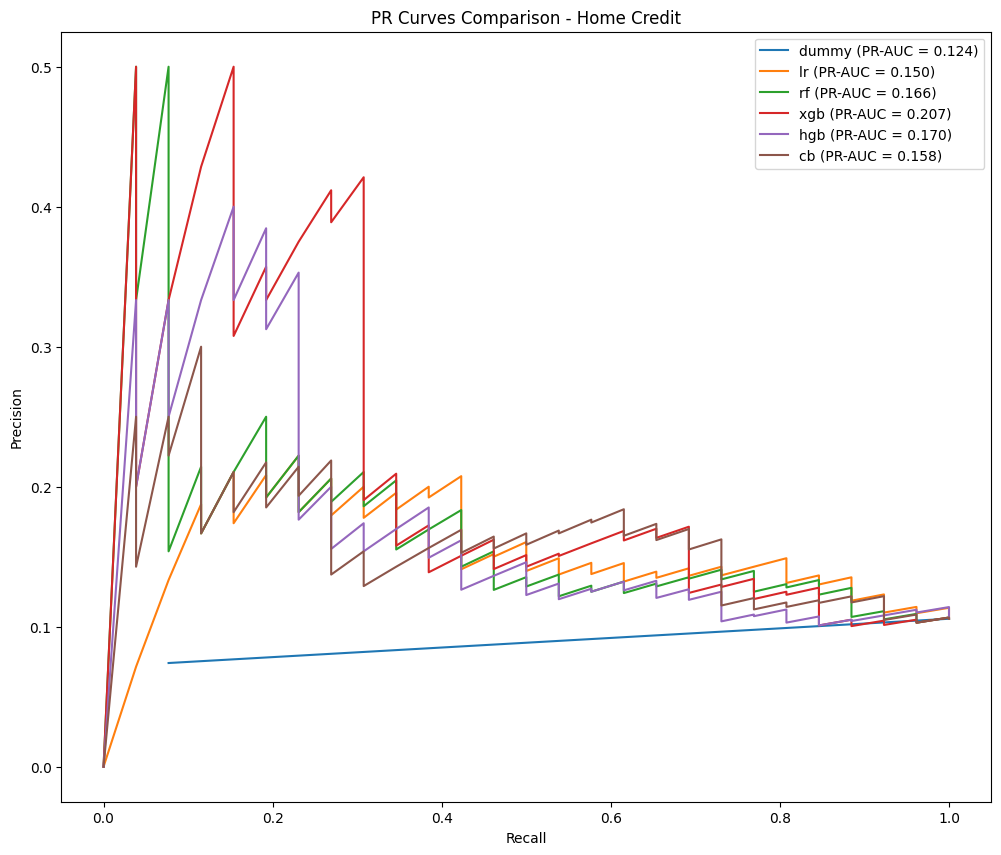

In [ ]:
# ===================== VISUALISATION & METRIQUES ============================
plt.figure(figsize=(12,10))

# On itère sur les pipelines pour tracer chaque courbe sur le même graphe
for name, pipe in pipelines.items():
    # Obtenir les probabilités via CV (Out-of-Fold)
    # On utilise une seule pipeline à la fois pour la mémoire
    df_pred = predict_models_cv(X_train, y_train, {name: pipe},n_jobs=n_jobs)
    
    # Calcul de la courbe PR
    prec, recall, threshold, pr_auc = \
        pr_curve(df_pred['True_Label'], df_pred['y_proba1'])
    
    # Tracé
    plt.plot(recall, prec, label=f'{name} (PR-AUC = {pr_auc:.3f})')
    
# Finalisation Graphique
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curves Comparison - Home Credit')
plt.legend()

# Sauvegarde de la courbe
save_figure("comparaison_modeles_courbes_pr", save_path/"figures")
mlflow.log_artifact(str(save_path/"figures/comparaison_modeles_courbes_pr"))

In [49]:
# ============================= MLFLOW END_RUN =====================================
# ------------------------------------------------------------------------------------

mlflow.end_run()

In [ ]:
# # réactive le log des modèles après CV
# mlflow.sklearn.autolog(disable = False) #type:ignore